### Outliers with z-score + visualization

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# load dataset
df = pd.read_csv("../winequality-red.csv")

# target variable
variable = "quality"
z_scores = stats.zscore(df[variable])

# Define a threshold for outliers
# modify this as needed, default is 3 (based on normal distribution)
# try this with 2 or 2.5, and then see how much data we lose 
# even if the distribution is closer to normal distribution now
threshold = 3

# Detect outliers
outliers = df[np.abs(z_scores) > threshold]

print("Detected outliers using Z-score:")
outliers

Detected outliers using Z-score:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.00,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.40,3
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.70,3
832,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.90,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.00,3
1299,7.6,1.580,0.00,2.10,0.137,5.0,9.0,0.99476,3.50,0.40,10.90,3
1374,6.8,0.815,0.00,1.20,0.267,16.0,29.0,0.99471,3.32,0.51,9.80,3
1469,7.3,0.980,0.05,2.10,0.061,20.0,49.0,0.99705,3.31,0.55,9.70,3
1478,7.1,0.875,0.05,5.70,0.082,3.0,14.0,0.99808,3.40,0.52,10.20,3
1505,6.7,0.760,0.02,1.80,0.078,6.0,12.0,0.99600,3.55,0.63,9.95,3


**This version of the visualization shows the dataset from 1st to last house in original order.**

We can see how scattered the outlier houses are based on price this way.

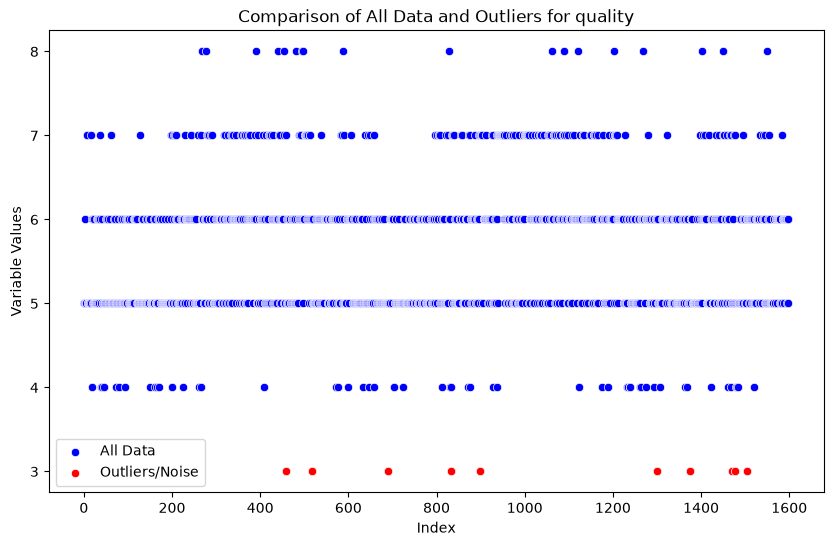

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot setup
plt.figure(figsize=(10, 6))

# which variable we are visualizing, usually a variable 
# we detected the outliers from or target variable
variable = "quality"

# NOTE! outliers is the dataframe that contains only the outliers or noise items

# Plot the full dataset (in blue, for example)
sns.scatterplot(x=df.index, y=df[variable], color='blue', label='All Data')

# Overlay the outliers (in red)
sns.scatterplot(x=outliers.index, y=outliers[variable], color='red', label='Outliers/Noise')

# Add title and labels
plt.title(f'Comparison of All Data and Outliers for {variable}')
plt.xlabel('Index')
plt.ylabel('Variable Values')

# Show legend
plt.legend()

# Display the plot
plt.show()

<Axes: >

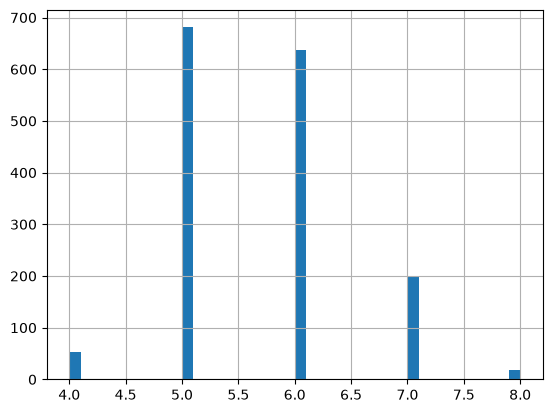

In [3]:
# take the original dataframe MINUS the outliers
inliers = df[~df.index.isin(outliers.index)]


inliers['quality'].hist(bins=40)

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("../winequality-red.csv")

variable = "quality"

# Calculate Q1, Q3, and IQR
Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Add outlier column: 1 = outlier, 0 = not an outlier
df["outlier"] = (
    (df[variable] < lower_bound) |
    (df[variable] > upper_bound)
).astype(int)

print(df["outlier"].value_counts())

outlier
0    1571
1      28
Name: count, dtype: int64


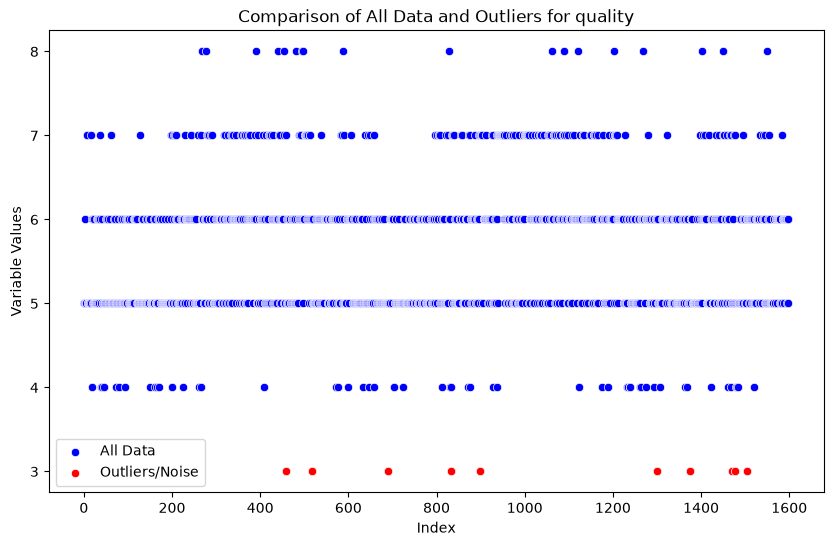

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot setup
plt.figure(figsize=(10, 6))

# which variable we are visualizing, usually a variable 
# we detected the outliers from or target variable
variable = "quality"

# NOTE! outliers is the dataframe that contains only the outliers or noise items

# Plot the full dataset (in blue, for example)
sns.scatterplot(x=df.index, y=df[variable], color='blue', label='All Data')

# Overlay the outliers (in red)
sns.scatterplot(x=outliers.index, y=outliers[variable], color='red', label='Outliers/Noise')

# Add title and labels
plt.title(f'Comparison of All Data and Outliers for {variable}')
plt.xlabel('Index')
plt.ylabel('Variable Values')

# Show legend
plt.legend()

# Display the plot
plt.show()

### EXTRA - pairplot for all variables (outliers)

This can be slow to generate, uncomment the code if you wish to try it.

In [6]:
# # Visualize
# import seaborn as sns

# sns.pairplot(
#     df,
#     vars=df.columns.drop("outlier"),
#     hue="outlier",
#     diag_kind="hist",
#     plot_kws={"alpha": 0.5}
# )

# plt.show()